<a href="https://colab.research.google.com/github/Thilac01/Image_Denoise/blob/main/Mora_SP_Cup_Colab_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mora SP Cup — Drive-first denoising notebook

Complete Colab workflow: discover folders → inspect paired images → split → train → compare → export offline inference → generate submission.

**Start:** Colab → Runtime → Change runtime type → GPU, then run cells in order. Add a shortcut to the organizer's dataset folder under **My Drive** before discovery. No download to your computer is required; images are read into Colab memory from mounted Drive. If your data is a ZIP, extract it into Drive first. Set the three explicit folder paths if discovery finds multiple copies.

The seven uploaded pages are competition rules, not a methods textbook. They specify 460 public pairs, 20 preliminary inputs, 992×992 images, offline CPU-capable inference, and a ZIP of exactly `461.png`–`480.png`. Classical techniques, report quality and CPU runtime also affect the overall assessment.

**Model:** a compact gated residual encoder–decoder inspired by NAFNet, implemented here from scratch; it is not the official NAFNet implementation or pretrained model. Reference: https://arxiv.org/abs/2204.04676 . A wavelet comparison and optional measured blend are included. No external training data or hidden targets are used.

**Limits:** This notebook has not been trained on your dataset. No score is promised. Its diagnostic RGB SSIM/PSNR and per-image score aggregation must be checked against the official evaluator. The official-evaluator cell displays the source and lets you run its documented arguments. Review the report and freeze requirements before submitting; a report is not fabricated automatically.


## 1 — Mount Drive
Expected: authorization followed by “Mounted at /content/drive”.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2 — Install dependencies
Uses Colab's existing PyTorch. Package versions are recorded later for the offline environment.


In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'pillow', 'numpy', 'pandas', 'matplotlib', 'scikit-image', 'tqdm'])


0

## 3 — Configuration
Edit `DRIVE_ROOT` for outputs; leave the three input paths empty to discover them. To restart a different experiment, change `RUN_NAME`. Defaults are conservative for a T4. `EPOCHS=40` is a starting budget, not a convergence guarantee. Use a new run when changing architecture, split, loss or schedule. Best checkpoint selection uses the clearly labeled diagnostic composite.

`CACHE_IMAGES=True` caches decoded **training** images in RAM on first use (about 2.4 GB for 414 RGB pairs). Set false if RAM is constrained; direct repeated Drive reads can be slow. Validation is never included in the training loader.


In [ ]:
from pathlib import Path
import os, json, random, time, hashlib, platform
import numpy as np
import pandas as pd
import torch

DRIVE_ROOT = Path('/content/drive/MyDrive/ImageDenoising')
RUN_NAME = 'gated_unet_01'
TRAIN_NOISY_PATH = ''  # e.g. /content/drive/MyDrive/dataset/public/noisy
TRAIN_CLEAN_PATH = ''  # folder containing 001.png ... 460.png
TEST_PATH = ''         # folder containing 461_noise.png ... 480_noise.png
SEARCH_ROOT = Path('/content/drive/MyDrive')
# Optional CSV with columns id,group for repeated captures of the same scene.
GROUPS_CSV = ''
TEAM_NAME = 'TeamName'
CFG = dict(seed=42, width=24, blocks=2, patch=192, batch=4,
           steps_per_epoch=150, epochs=40, lr=2e-4, weight_decay=1e-4,
           ssim_weight=0.0, ema_decay=0.995, val_fraction=0.10,
           patience=10, tile=384, overlap=64, amp=True,
           cache_images=True, num_workers=0)
RESUME = True
RUN = DRIVE_ROOT / 'runs' / RUN_NAME
SCRIPTS = RUN / 'scripts'
CKPT = RUN / 'checkpoints'
for p in (RUN, SCRIPTS, CKPT): p.mkdir(parents=True, exist_ok=True)
random.seed(CFG['seed']); np.random.seed(CFG['seed']); torch.manual_seed(CFG['seed'])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(CFG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('VRAM GiB:', round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2))
else:
    print('CPU active: inference works, but select a GPU before training.')
print('Outputs:', RUN)


Tesla T4
VRAM GiB: 14.56
Outputs: /content/drive/MyDrive/ImageDenoising/runs/gated_unet_01


## 4 — Find the actual dataset folders (fixes the previous error)
Searches filenames without copying images. If there are multiple candidates, paste the intended paths into Cell 3. No ambiguous candidate is silently chosen. For a missing folder, add the dataset shortcut in Drive and remount; a shared web link alone is not a mounted directory.


In [ ]:
from google.colab import drive
from pathlib import Path
import tempfile
import json

# Create an empty mount directory without deleting existing files.
MOUNT_ROOT = Path(tempfile.mkdtemp(prefix="mora_drive_", dir="/content"))
drive.mount(str(MOUNT_ROOT))

MY_DRIVE = MOUNT_ROOT / "MyDrive"
DATASET_ROOT = MY_DRIVE / "Dataset"

TRAIN_NOISY_DIR = DATASET_ROOT / "public" / "noisy"
TRAIN_CLEAN_DIR = DATASET_ROOT / "public" / "ground_truth"
TEST_DIR = DATASET_ROOT / "submissions" / "noisy"

paths = {
    "train_noisy": TRAIN_NOISY_DIR,
    "train_clean": TRAIN_CLEAN_DIR,
    "test": TEST_DIR,
}

for name, folder in paths.items():
    if not folder.is_dir():
        raise FileNotFoundError(
            f"Cannot access: {folder}\n"
            "Authorize the same Google account shown in your screenshot."
        )

    count = sum(1 for p in folder.glob("*.png") if p.is_file())
    print(f"{name}: {count} PNG images")

# Update ALL output paths to the newly mounted real Google Drive.
DRIVE_ROOT = MY_DRIVE / "ImageDenoising"
SEARCH_ROOT = MY_DRIVE
RUN = DRIVE_ROOT / "runs" / RUN_NAME
SCRIPTS = RUN / "scripts"
CKPT = RUN / "checkpoints"

for folder in (RUN, SCRIPTS, CKPT):
    folder.mkdir(parents=True, exist_ok=True)

(RUN / "paths.json").write_text(
    json.dumps({name: str(path) for name, path in paths.items()}, indent=2)
)

print("\nOutputs will be saved to:", RUN)
print("SUCCESS — continue with Cell 5.")

Mounted at /content/mora_drive_kkysk34l
train_noisy: 460 PNG images
train_clean: 460 PNG images
test: 20 PNG images

Outputs will be saved to: /content/mora_drive_kkysk34l/MyDrive/ImageDenoising/runs/gated_unet_01
SUCCESS — continue with Cell 5.


## 5 — Audit every image and pair
Expected: 460 pairs and 20 test inputs. PNG, JPEG and TIFF can be decoded for inspection, but official inputs must keep their documented PNG filenames. The model supports uint8 grayscale and RGB; unusual bit depth, alpha or palette formats trigger a clear stop, not a destructive conversion.


In [ ]:
from PIL import Image
from tqdm.auto import tqdm
EXTS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
def index_folder(folder, noisy):
    result = {}
    for p in sorted(folder.iterdir()):
        if p.suffix.lower() not in EXTS or not p.is_file(): continue
        m = re.fullmatch(r'(\d+)_noise' if noisy else r'(\d+)', p.stem)
        if not m: raise ValueError(f'Unexpected image filename: {p.name}')
        i = int(m.group(1))
        if i in result: raise ValueError(f'Duplicate ID: {i}')
        result[i] = p
    return result
noisy_paths = index_folder(TRAIN_NOISY_DIR, True)
clean_paths = index_folder(TRAIN_CLEAN_DIR, False)
test_paths = index_folder(TEST_DIR, True)
for label, mapping, expected in [('noisy', noisy_paths, set(range(1,461))),
                                  ('clean', clean_paths, set(range(1,461))),
                                  ('test', test_paths, set(range(461,481)))]:
    if set(mapping) != expected:
        raise ValueError(f'{label}: missing={sorted(expected-set(mapping))}; extra={sorted(set(mapping)-expected)}')
    for i, p in mapping.items():
        expected_name = f'{i:03d}_noise.png' if label != 'clean' else f'{i:03d}.png'
        if p.name != expected_name: raise ValueError(f'Official filename expected: {expected_name}, found {p.name}')
records=[]
for label, mapping in [('noisy',noisy_paths),('clean',clean_paths),('test',test_paths)]:
    for i,p in tqdm(mapping.items(), desc=label):
        with Image.open(p) as im:
            im.load(); a=np.asarray(im)
            records.append(dict(split=label,id=i,path=str(p),mode=im.mode,
                                width=im.width,height=im.height,dtype=str(a.dtype),
                                minimum=int(a.min()),maximum=int(a.max()),mean=float(a.mean()),std=float(a.std())))
            if im.mode not in ('RGB','L') or a.dtype != np.uint8:
                raise ValueError(f'{p}: mode={im.mode}, dtype={a.dtype}; explicit format handling required.')
            if im.size != (992,992): raise ValueError(f'{p}: expected 992×992, got {im.size}')
audit=pd.DataFrame(records)
audit.to_csv(RUN/'image_inventory.csv',index=False)
if audit['mode'].nunique()!=1: raise ValueError('Mixed channel modes require a separate training configuration.')
CHANNELS=3 if audit.iloc[0]['mode']=='RGB' else 1
CFG['channels']=CHANNELS
print('Channels:',CHANNELS)
display(audit.groupby(['split','mode','dtype','width','height']).size().rename('count').reset_index())
print('PASS: all pairs decoded; official counts, formats and sizes checked.')


noisy:   0%|          | 0/460 [00:00<?, ?it/s]

clean:   0%|          | 0/460 [00:00<?, ?it/s]

test:   0%|          | 0/20 [00:00<?, ?it/s]

Channels: 3


,split,mode,dtype,width,height,count
0,clean,RGB,uint8,992,992,460
1,noisy,RGB,uint8,992,992,460
2,test,RGB,uint8,992,992,20


PASS: all pairs decoded; official counts, formats and sizes checked.


## 6 — Official evaluator source (optional access; recommended verification)
The documented formula is implemented below as a diagnostic with RGB SSIM defaults. Exact official SSIM settings, rounding, border treatment and aggregation remain unverified until this source is inspected. If cloning fails, put the official repository in `STARTER` manually. This cell does not execute downloaded Python.


In [ ]:
STARTER = DRIVE_ROOT / 'mora_sp_cup_2026'
url='https://github.com/moraspcup-official/mora_sp_cup_2026.git'
if not STARTER.exists():
    result=subprocess.run(['git','clone',url,str(STARTER)],capture_output=True,text=True)
    if result.returncode: print('Repository not accessible:',result.stderr[-1500:])
evaluator=STARTER/'evaluation'/'evaluate.py'
if evaluator.is_file():
    print(evaluator.read_text())
else:
    print('Official evaluator unavailable. Scores in this notebook remain DIAGNOSTIC.')


#!/usr/bin/env python3
"""
evaluate.py
-----------------------
Computes the denoising score for a set of images. This is a self-check
tool: it reads the noisy input, your denoised output, and the ground-truth
images, then reports the mean PSNR, SSIM, and composite score.

USAGE (three required paths):
    python evaluate.py \
        --noisy_dir noise_test \
        --pred_dir my_outputs \
        --gt_dir ground_truth_test

Filename convention:
    ground_truth_test/001.png          <- ground truth
    noise_test/001_noise.png            <- noisy input (given to you)
    my_outputs/001.png                   <- YOUR reconstruction (same id, NO suffix)

"""

from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
from PIL import Image, UnidentifiedImageError
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim


def ssim_value(a: np.ndarray, b: np.ndarray) -> float:
    return

## 7 — Reusable image IO and diagnostic metrics
Each image is scored after conversion to the same uint8 values written to PNG. This avoids optimistic float-only validation. Infinite PSNR is supported for perfect matches; undefined improvement for an already-perfect noisy image is handled explicitly.


In [ ]:
CORE_IO = "import math, re\nfrom pathlib import Path\nimport numpy as np\nfrom PIL import Image\nimport torch\nfrom torch import nn\nimport torch.nn.functional as F\nfrom skimage.metrics import peak_signal_noise_ratio, structural_similarity\n\ndef read_image(path):\n    with Image.open(path) as im:\n        a=np.asarray(im)\n        if im.mode not in ('RGB','L') or a.dtype!=np.uint8:\n            raise ValueError(f'Only uint8 RGB/L supported: {path}, {im.mode}, {a.dtype}')\n    if a.ndim==2: a=a[...,None]\n    return np.array(a,copy=True)\n\ndef quantize(a):\n    return np.rint(np.clip(a,0,1)*255).astype(np.uint8)\n\ndef write_image(path,a):\n    a=quantize(a)\n    Image.fromarray(a[...,0] if a.shape[-1]==1 else a).save(path)\n\ndef metric_row(noisy,clean,pred):\n    x=clean.astype(np.float64)/255\n    y=noisy.astype(np.float64)/255\n    z=quantize(pred).astype(np.float64)/255\n    def pair(a,b):\n        channel_axis=-1 if a.shape[-1]>1 else None\n        if channel_axis is None: a,b=a[...,0],b[...,0]\n        return (float(peak_signal_noise_ratio(a,b,data_range=1)),\n                float(structural_similarity(a,b,data_range=1,channel_axis=channel_axis)))\n    pn,sn=pair(x,y); pp,sp=pair(x,z)\n    dp=pp-pn if math.isfinite(pn) else (0.0 if not math.isfinite(pp) else -math.inf)\n    score=.6*np.clip(dp/15,0,1)+.4*max(sp-sn,0)\n    return dict(psnr=pp,ssim=sp,noisy_psnr=pn,noisy_ssim=sn,\n                delta_psnr=dp,delta_ssim=sp-sn,score=float(score),\n                mse=float(np.mean((x-z)**2)),mae=float(np.mean(np.abs(x-z))))\n"
(SCRIPTS/'denoise_core.py').write_text(CORE_IO)
import sys
sys.path.insert(0,str(SCRIPTS))
from denoise_core import read_image, quantize, write_image, metric_row
print('IO and diagnostic metrics ready.')


IO and diagnostic metrics ready.


## 8 — Noise analysis and paired examples
Residual mean/variance versus clean brightness are clues, not proof of a particular noise distribution. Uses public pairs only. Saves PNGs and a CSV to Drive.


,id,noisy_psnr,noisy_ssim,residual_mean,residual_std
0,13,23.522299,0.559998,0.010752,0.065790
1,53,17.075479,0.607506,0.012367,0.139484
2,58,17.088604,0.565210,0.031026,0.136334
3,72,18.736806,0.588287,0.005033,0.115544
4,115,23.140790,0.514078,-0.001163,0.069647
5,126,20.434667,0.196967,0.006707,0.094882
6,141,18.245870,0.551838,0.008675,0.122071
7,328,18.762388,0.251621,-0.014669,0.114377
8,347,22.402558,0.476641,0.005973,0.075600
9,378,20.482291,0.485561,-0.001909,0.094580


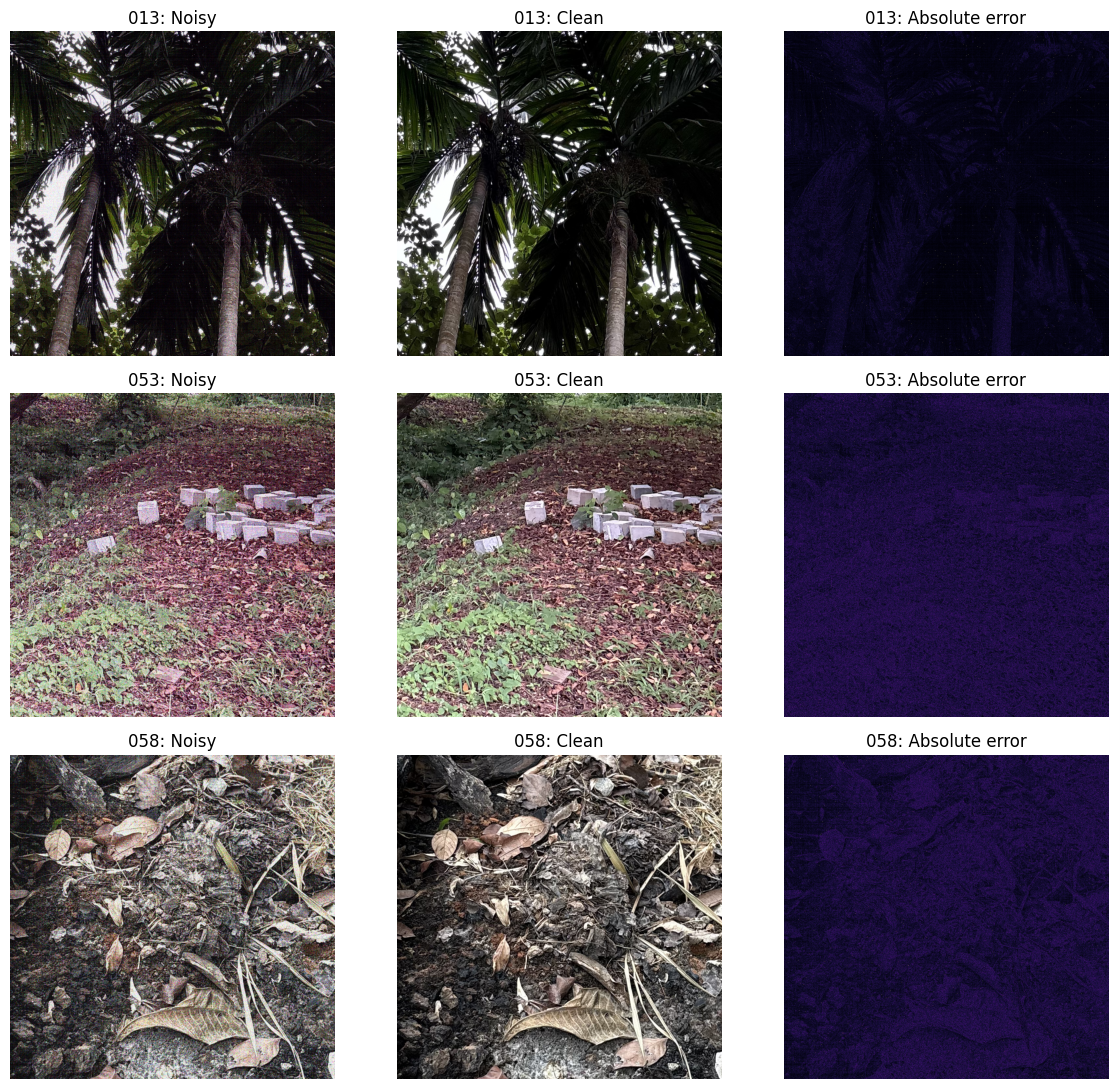

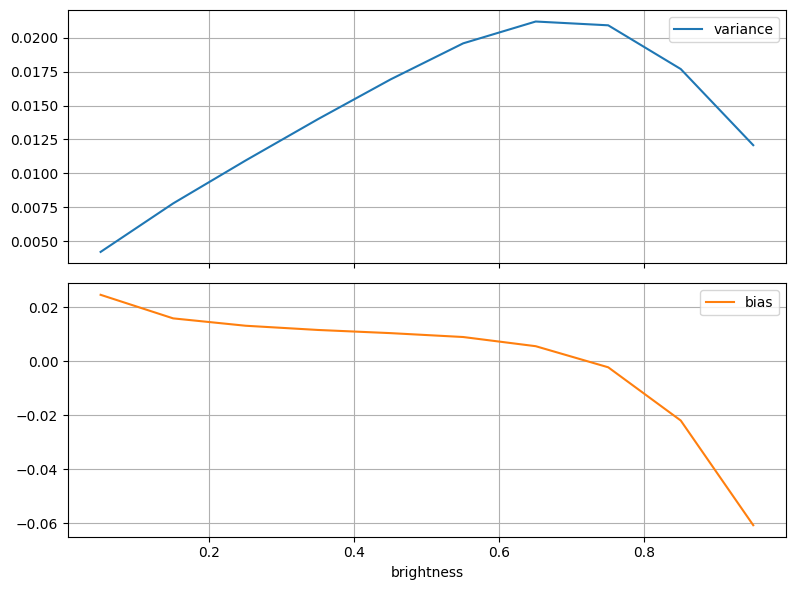

In [ ]:
import matplotlib.pyplot as plt
sample_ids=sorted(random.Random(CFG['seed']).sample(list(noisy_paths),12))
rows=[]; bins=[]
for i in sample_ids:
    y=read_image(noisy_paths[i]); x=read_image(clean_paths[i]); d=(y.astype(float)-x)/255
    rows.append(dict(id=i,**metric_row(y,x,y/255),residual_mean=d.mean(),residual_std=d.std()))
    brightness=x.mean(-1)/255
    for b in range(10):
        mask=(brightness>=b/10)&(brightness<(b+1)/10 if b<9 else brightness<=1)
        if mask.sum()>100: bins.append(dict(id=i,brightness=(b+.5)/10,variance=d[mask].var(),bias=d[mask].mean()))
pd.DataFrame(rows).to_csv(RUN/'noise_diagnostics.csv',index=False)
pd.DataFrame(bins).to_csv(RUN/'noise_brightness.csv',index=False)
display(pd.DataFrame(rows)[['id','noisy_psnr','noisy_ssim','residual_mean','residual_std']])
fig,axes=plt.subplots(3,3,figsize=(12,11))
for row,i in enumerate(sample_ids[:3]):
    y=read_image(noisy_paths[i])/255; x=read_image(clean_paths[i])/255
    for col,a in enumerate([y,x,np.abs(y-x).mean(-1)]):
        axes[row,col].imshow(a.squeeze(),cmap='magma' if col==2 else 'gray')
        axes[row,col].set_title(f'{i:03d}: '+['Noisy','Clean','Absolute error'][col]); axes[row,col].axis('off')
plt.tight_layout(); fig.savefig(RUN/'paired_examples.png',dpi=150); plt.show()
pd.DataFrame(bins).groupby('brightness')[['variance','bias']].mean().plot(subplots=True,figsize=(8,6),grid=True)
plt.tight_layout(); plt.savefig(RUN/'noise_brightness.png',dpi=150); plt.show()


## 9 — Fixed image-level split and duplicate grouping
Exact duplicates of the decoded clean image are kept together automatically. For near-duplicate scenes/bursts, supply `GROUPS_CSV` (columns `id,group`, all 460 IDs); inspect the saved validation contact sheet. Patches are drawn only after splitting. Freeze the split across experiments. A random split cannot by itself detect related scenes.


Grouping exact duplicates:   0%|          | 0/460 [00:00<?, ?it/s]

Train: 414 Validation: 46


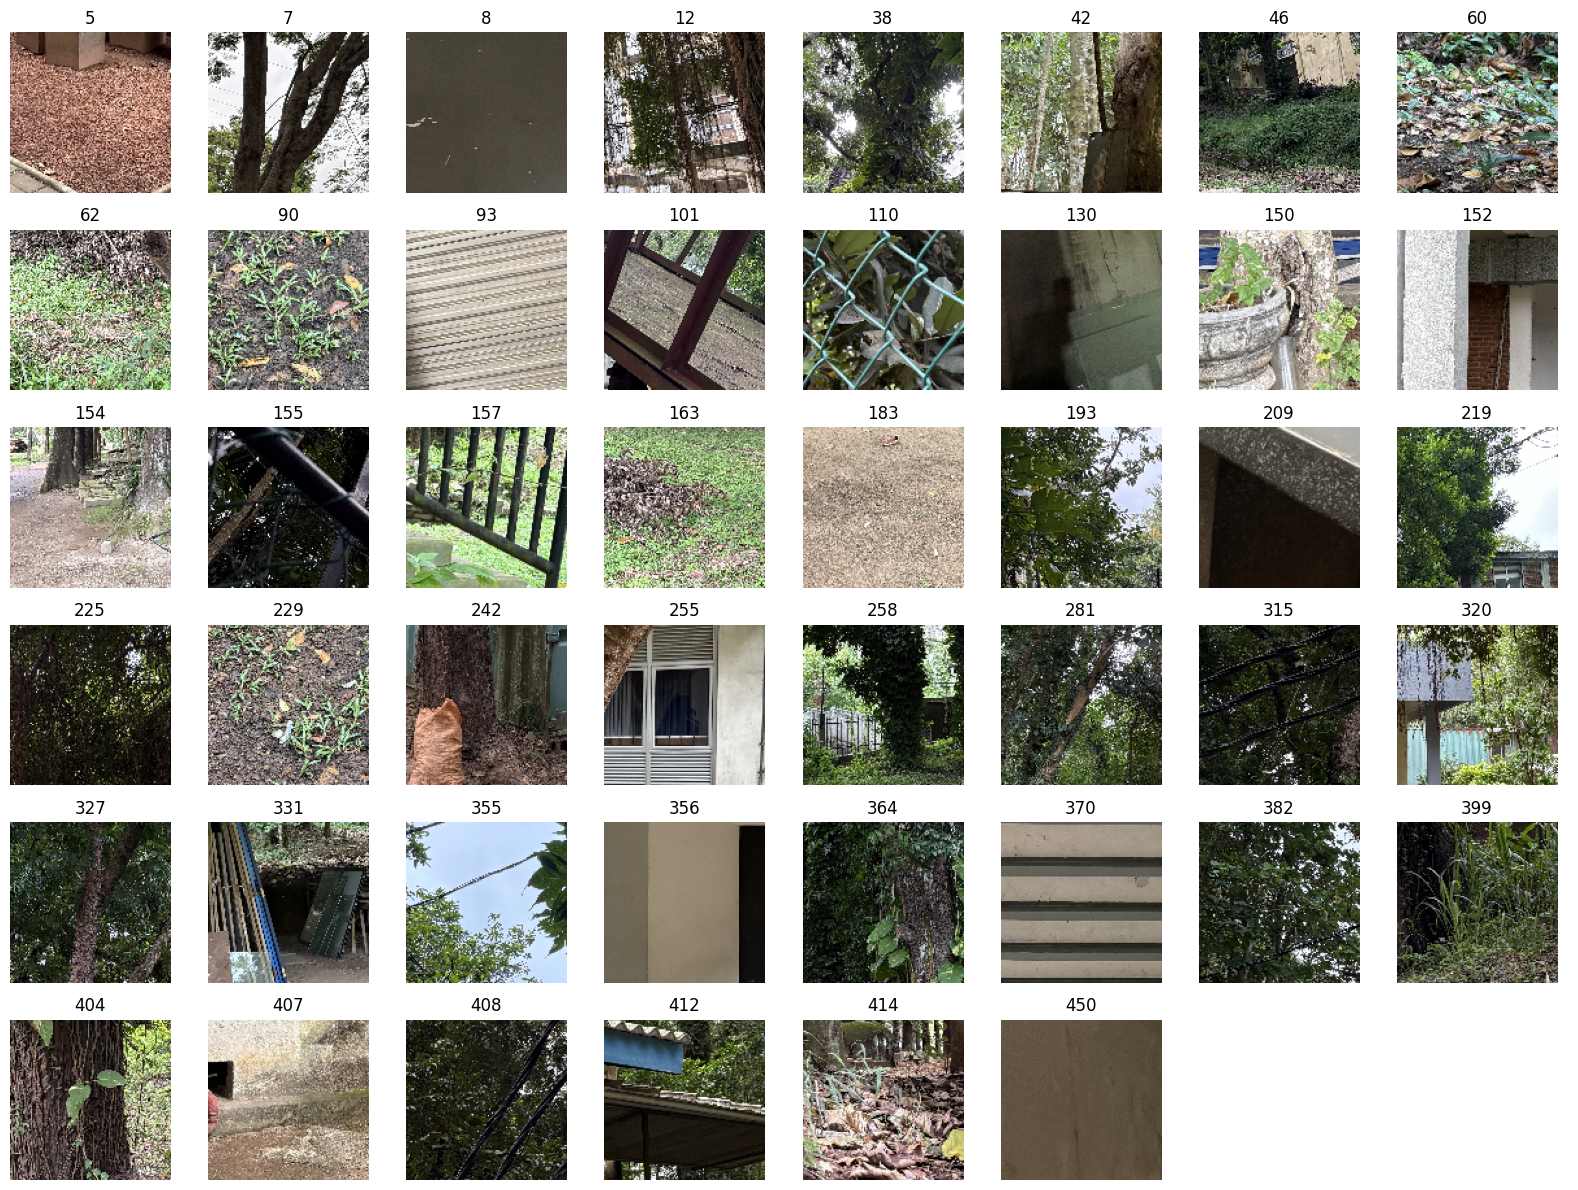

In [ ]:
parent={i:i for i in clean_paths}
def root(i):
    while parent[i]!=i:
        parent[i]=parent[parent[i]]; i=parent[i]
    return i
def union(a,b): parent[root(b)]=root(a)
seen={}
for i,p in tqdm(clean_paths.items(),desc='Grouping exact duplicates'):
    digest=hashlib.sha256(read_image(p).tobytes()).hexdigest()
    if digest in seen: union(i,seen[digest])
    else: seen[digest]=i
if GROUPS_CSV:
    groups=pd.read_csv(GROUPS_CSV)
    if groups['id'].duplicated().any() or set(groups['id'])!=set(clean_paths) or groups['group'].isna().any():
        raise ValueError('groups CSV must contain each public ID exactly once, with nonempty groups.')
    for _,g in groups.groupby('group'):
        ids=g['id'].astype(int).tolist()
        for i in ids[1:]: union(ids[0],i)
clusters={}
for i in clean_paths: clusters.setdefault(root(i),[]).append(i)
keys=list(clusters); random.Random(CFG['seed']).shuffle(keys)
val_ids=[]
for key in keys:
    if len(val_ids)>=round(len(clean_paths)*CFG['val_fraction']): break
    val_ids.extend(clusters[key])
val_ids=sorted(val_ids); train_ids=sorted(set(clean_paths)-set(val_ids))
if not train_ids or not val_ids: raise ValueError('Grouping produced an empty split.')
split={'train':train_ids,'val':val_ids}
split_path=RUN/'split.json'
if split_path.exists() and json.loads(split_path.read_text())!=split:
    raise RuntimeError('Existing split differs. Use a new RUN_NAME for this change.')
split_path.write_text(json.dumps(split,indent=2))
print('Train:',len(train_ids),'Validation:',len(val_ids))
cols=8; nrows=(len(val_ids)+cols-1)//cols
fig,axes=plt.subplots(nrows,cols,figsize=(16,2*nrows),squeeze=False)
for ax in axes.flat: ax.axis('off')
for ax,i in zip(axes.flat,val_ids):
    ax.imshow(read_image(clean_paths[i])[::8,::8].squeeze(),cmap='gray'); ax.set_title(str(i))
plt.tight_layout(); fig.savefig(RUN/'validation_contact_sheet.png',dpi=120); plt.show()


## 10 — Gated residual model
Three downsampling stages, channel-wise normalization and multiplicative gates; predicts an additive correction. No brightness normalization is independently applied to noisy and clean data. This is a compact custom design, not an exact reproduction of NAFNet.


In [ ]:
CORE_MODEL = "\nclass ChannelNorm(nn.Module):\n    def __init__(self,c):\n        super().__init__(); self.w=nn.Parameter(torch.ones(1,c,1,1)); self.b=nn.Parameter(torch.zeros(1,c,1,1))\n    def forward(self,x):\n        dtype=x.dtype; z=x.float(); mu=z.mean(1,keepdim=True)\n        z=(z-mu)*torch.rsqrt((z-mu).square().mean(1,keepdim=True)+1e-6)\n        return (z*self.w+self.b).to(dtype)\n\nclass GatedBlock(nn.Module):\n    def __init__(self,c):\n        super().__init__()\n        self.n1=ChannelNorm(c); self.n2=ChannelNorm(c)\n        self.expand=nn.Conv2d(c,2*c,1); self.depth=nn.Conv2d(2*c,2*c,3,padding=1,groups=2*c)\n        self.attn=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Conv2d(c,c,1))\n        self.project=nn.Conv2d(c,c,1); self.f1=nn.Conv2d(c,2*c,1); self.f2=nn.Conv2d(c,c,1)\n        self.beta=nn.Parameter(torch.zeros(1,c,1,1)); self.gamma=nn.Parameter(torch.zeros(1,c,1,1))\n    def forward(self,x):\n        a,b=self.depth(self.expand(self.n1(x))).chunk(2,1); z=a*b\n        x=x+self.beta*self.project(z*self.attn(z))\n        a,b=self.f1(self.n2(x)).chunk(2,1)\n        return x+self.gamma*self.f2(a*b)\n\nclass Denoiser(nn.Module):\n    def __init__(self,channels=3,width=24,blocks=2):\n        super().__init__(); self.channels=channels\n        self.head=nn.Conv2d(channels,width,3,padding=1)\n        self.enc=nn.ModuleList(); self.down=nn.ModuleList(); self.up=nn.ModuleList(); self.dec=nn.ModuleList()\n        c=width\n        for _ in range(3):\n            self.enc.append(nn.Sequential(*[GatedBlock(c) for _ in range(blocks)]))\n            self.down.append(nn.Conv2d(c,2*c,2,stride=2)); c*=2\n        self.mid=nn.Sequential(*[GatedBlock(c) for _ in range(blocks+2)])\n        for _ in range(3):\n            self.up.append(nn.Sequential(nn.Conv2d(c,2*c,1),nn.PixelShuffle(2))); c//=2\n            self.dec.append(nn.Sequential(*[GatedBlock(c) for _ in range(blocks)]))\n        self.tail=nn.Conv2d(width,channels,3,padding=1)\n        nn.init.zeros_(self.tail.weight); nn.init.zeros_(self.tail.bias)\n    def forward(self,x):\n        h,w=x.shape[-2:]; p=F.pad(x,(0,(-w)%8,0,(-h)%8),mode='replicate')\n        z=self.head(p); skips=[]\n        for enc,down in zip(self.enc,self.down): z=enc(z); skips.append(z); z=down(z)\n        z=self.mid(z)\n        for up,dec,s in zip(self.up,self.dec,reversed(skips)): z=dec(up(z)+s)\n        return (p+self.tail(z))[...,:h,:w]\n"
with (SCRIPTS/'denoise_core.py').open('a') as f: f.write(CORE_MODEL)
import importlib, denoise_core
importlib.reload(denoise_core)
from denoise_core import Denoiser
model=Denoiser(CHANNELS,CFG['width'],CFG['blocks']).to(DEVICE)
print('Parameters:',sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    probe=torch.rand(1,CHANNELS,65,71,device=DEVICE)
    assert model(probe).shape==probe.shape
    assert torch.allclose(model(probe),probe)
print('PASS: arbitrary-size shape and initial identity checks.')


Parameters: 1614267
PASS: arbitrary-size shape and initial identity checks.


## 11 — Overlap-tiled inference, eight-way TTA and optional ensemble
Positive blending weights prevent uncovered borders. TTA is disabled by default and benchmarked later. Full-image and tiled results can differ because channel attention uses local tile statistics, so validation uses the same tile settings as submission.


In [ ]:
CORE_INFERENCE = "\ndef tiled(model,x,tile=384,overlap=64):\n    if tile<=overlap or overlap<0: raise ValueError('Require 0 <= overlap < tile')\n    h,w=x.shape[-2:]\n    if h<=tile and w<=tile: return model(x).float()\n    def starts(n):\n        if n<=tile: return [0]\n        return sorted(set(list(range(0,n-tile+1,tile-overlap))+[n-tile]))\n    out=torch.zeros_like(x,dtype=torch.float32); weights=torch.zeros_like(x[:,:1],dtype=torch.float32)\n    for top in starts(h):\n        for left in starts(w):\n            patch=x[...,top:top+tile,left:left+tile]; ph,pw=patch.shape[-2:]\n            wy=torch.hann_window(ph,periodic=False,device=x.device).clamp_min(.05)\n            wx=torch.hann_window(pw,periodic=False,device=x.device).clamp_min(.05)\n            weight=(wy[:,None]*wx[None,:])[None,None]\n            out[...,top:top+ph,left:left+pw]+=model(patch).float()*weight\n            weights[...,top:top+ph,left:left+pw]+=weight\n    return out/weights\n\ndef transform(x,k,flip):\n    x=torch.rot90(x,k,(-2,-1))\n    return x.flip(-1) if flip else x\n\ndef invert(x,k,flip):\n    if flip: x=x.flip(-1)\n    return torch.rot90(x,-k,(-2,-1))\n\n@torch.inference_mode()\ndef predict(model,array,device,tile=384,overlap=64,tta=False):\n    x=torch.from_numpy(np.ascontiguousarray(array.transpose(2,0,1))).float()[None].to(device)/255\n    total=torch.zeros_like(x,dtype=torch.float32)\n    variants=[(k,f) for k in range(4) for f in (False,True)] if tta else [(0,False)]\n    model.eval()\n    for k,f in variants:\n        z=transform(x,k,f)\n        out=tiled(model,z,tile,overlap)\n        total+=invert(out,k,f)\n    result=(total/len(variants)).clamp(0,1)[0].permute(1,2,0).cpu().numpy()\n    if not np.isfinite(result).all(): raise FloatingPointError('Nonfinite prediction')\n    return result\n\ndef wavelet_prediction(array):\n    from skimage.restoration import denoise_wavelet\n    x=array.astype(np.float32)/255\n    if x.shape[-1]==1:\n        out=denoise_wavelet(x[...,0],method='BayesShrink',mode='soft',rescale_sigma=True,channel_axis=None)[...,None]\n    else:\n        out=denoise_wavelet(x,method='BayesShrink',mode='soft',rescale_sigma=True,channel_axis=-1,convert2ycbcr=True)\n    return np.clip(out,0,1).astype(np.float32)\n\ndef load_model(path,device):\n    # Only load checkpoints produced by this notebook / otherwise trusted.\n    state=torch.load(path,map_location='cpu',weights_only=False)\n    c=state['config']; model=Denoiser(c['channels'],c['width'],c['blocks'])\n    model.load_state_dict(state['model']); return model.to(device).eval()\n\ndef ensemble_predict(models,weights,array,device,tile=384,overlap=64,tta=False):\n    weights=np.asarray(weights,dtype=float)\n    if len(models)!=len(weights) or np.any(weights<0) or weights.sum()<=0:\n        raise ValueError('Provide one nonnegative weight per model with positive sum')\n    result=np.zeros(array.shape,dtype=np.float32)\n    for m,w in zip(models,weights/weights.sum()): result+=float(w)*predict(m,array,device,tile,overlap,tta)\n    return result\n"
with (SCRIPTS/'denoise_core.py').open('a') as f: f.write(CORE_INFERENCE)
importlib.reload(denoise_core)
from denoise_core import predict, tiled, transform, invert, wavelet_prediction, load_model, ensemble_predict
probe=torch.rand(1,CHANNELS,65,71,device=DEVICE)
for k in range(4):
    for f in (False,True): assert torch.equal(invert(transform(probe,k,f),k,f),probe)
with torch.no_grad():
    assert torch.allclose(tiled(torch.nn.Identity(),probe,32,8),probe,atol=1e-6)
print('PASS: all TTA inverses and identity tile blending.')


PASS: all TTA inverses and identity tile blending.


## 12 — Aligned random-patch training loader
Shared crops, flips and rotations preserve pairing. No synthetic Gaussian noise is assumed. RAM caching stores uint8 arrays; conversion happens after cropping. Worker count stays zero for reliable notebook resume and a shared cache.


In [ ]:
from torch.utils.data import Dataset, DataLoader
class PairedPatches(Dataset):
    def __init__(self,ids): self.ids=ids; self.cache={}
    def __len__(self): return CFG['steps_per_epoch']*CFG['batch']
    def __getitem__(self,index):
        i=random.choice(self.ids)
        if i in self.cache: y,x=self.cache[i]
        else:
            y,x=read_image(noisy_paths[i]),read_image(clean_paths[i])
            if CFG['cache_images']: self.cache[i]=(y,x)
        p=CFG['patch']; h,w=y.shape[:2]
        if p>min(h,w): raise ValueError('Patch larger than source image')
        top=random.randrange(h-p+1); left=random.randrange(w-p+1)
        y=y[top:top+p,left:left+p]; x=x[top:top+p,left:left+p]
        k=random.randrange(4); y=np.rot90(y,k); x=np.rot90(x,k)
        if random.random()<.5: y=y[:,::-1]; x=x[:,::-1]
        return tuple(torch.from_numpy(np.ascontiguousarray(a.transpose(2,0,1))).float()/255 for a in (y,x))
train_data=PairedPatches(train_ids)
loader=DataLoader(train_data,batch_size=CFG['batch'],num_workers=0,
                  pin_memory=DEVICE.type=='cuda')
y,x=next(iter(loader))
assert y.shape==x.shape==(CFG['batch'],CHANNELS,CFG['patch'],CFG['patch'])
print('Batch:',y.shape,'range:',float(y.min()),float(y.max()))


Batch: torch.Size([4, 3, 192, 192]) range: 0.0 1.0


## 13 — Loss, optimizer, EMA and complete resume
MSE is the default. Set `ssim_weight=0.02` in a **new run** to test a structural term; this training SSIM surrogate is not the official evaluator. Checkpoints save optimizer, scheduler, scaler, EMA, random states, configuration, split and history. Resume is at the last completed epoch; interrupted epoch work is repeated. Only load trusted checkpoints.


In [ ]:
import copy, math
import torch.nn.functional as F

def structural_loss(a,b):
    a,b=a.float(),b.float()
    mu_a=F.avg_pool2d(a,7,1); mu_b=F.avg_pool2d(b,7,1)
    va=F.avg_pool2d(a*a,7,1)-mu_a*mu_a
    vb=F.avg_pool2d(b*b,7,1)-mu_b*mu_b
    cov=F.avg_pool2d(a*b,7,1)-mu_a*mu_b
    s=((2*mu_a*mu_b+.01**2)*(2*cov+.03**2))/((mu_a.square()+mu_b.square()+.01**2)*(va+vb+.03**2))
    return 1-s.mean()

def loss_fn(pred,target):
    loss=F.mse_loss(pred.float(),target.float())
    if CFG['ssim_weight']: loss+=CFG['ssim_weight']*structural_loss(pred,target)
    return loss

ema=copy.deepcopy(model).eval()
for p in ema.parameters(): p.requires_grad_(False)
optimizer=torch.optim.AdamW(model.parameters(),lr=CFG['lr'],weight_decay=CFG['weight_decay'])
def lr_factor(epoch):
    if epoch<3: return (epoch+1)/3
    progress=min(1,max(0,(epoch-3)/max(1,CFG['epochs']-3)))
    return .05+.95*.5*(1+math.cos(math.pi*progress))
scheduler=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_factor)
AMP=CFG['amp'] and DEVICE.type=='cuda'
scaler=torch.amp.GradScaler('cuda',enabled=AMP)
start_epoch=0; history=[]; best_score=-float('inf'); best_psnr=-float('inf'); best_ssim=-float('inf'); stale=0

def atomic_save(obj,path):
    tmp=path.with_suffix(path.suffix+'.tmp'); torch.save(obj,tmp); os.replace(tmp,path)

def save_best(net,path,epoch,metrics):
    atomic_save({'model':{k:v.detach().cpu() for k,v in net.state_dict().items()},
                 'config':dict(CFG),'epoch':epoch,'metrics':metrics,'split':split},path)

last=CKPT/'last_model.pth'
if RESUME and last.is_file():
    state=torch.load(last,map_location='cpu',weights_only=False)
    if state['config']!=CFG or state['split']!=split:
        raise ValueError('Resume configuration/split differs. Restore config or choose a new RUN_NAME.')
    model.load_state_dict(state['model']); ema.load_state_dict(state['ema'])
    optimizer.load_state_dict(state['optimizer']); scheduler.load_state_dict(state['scheduler'])
    scaler.load_state_dict(state['scaler'])
    start_epoch=state['epoch']+1; history=state['history']
    best_score=state['best_score']; best_psnr=state['best_psnr']; best_ssim=state['best_ssim']; stale=state['stale']
    random.setstate(state['random']); np.random.set_state(state['numpy']); torch.set_rng_state(state['torch'])
    if DEVICE.type=='cuda' and state['cuda'] is not None: torch.cuda.set_rng_state_all(state['cuda'])
    print('Resuming at epoch',start_epoch+1)
elif not RESUME and last.is_file():
    raise RuntimeError('Existing run found. Use a new RUN_NAME to avoid overwriting experiments.')
(RUN/'config.json').write_text(json.dumps(CFG,indent=2))
print('AMP:',AMP,'Starting epoch:',start_epoch+1)


AMP: True Starting epoch: 1


## 14 — Full-image validation and classical baseline
Validation metrics use saved-image quantization and the documented composite formula, with unverified official SSIM settings. Wavelet results provide a meaningful classical reference; they do not automatically earn a competition category score.


In [ ]:
def evaluate(net=None,tta=False,classical=False,save_dir=None):
    rows=[]
    if save_dir: save_dir.mkdir(parents=True,exist_ok=True)
    for i in tqdm(val_ids,desc='Validation',leave=False):
        y=read_image(noisy_paths[i]); x=read_image(clean_paths[i]); begin=time.perf_counter()
        pred=wavelet_prediction(y) if classical else predict(net,y,DEVICE,CFG['tile'],CFG['overlap'],tta)
        if DEVICE.type=='cuda': torch.cuda.synchronize()
        rows.append(dict(id=i,seconds=time.perf_counter()-begin,**metric_row(y,x,pred)))
        if save_dir: write_image(save_dir/f'{i:03d}.png',pred)
    frame=pd.DataFrame(rows)
    return frame,frame.drop(columns='id').mean().to_dict()
classical_frame,classical_metrics=evaluate(classical=True)
classical_frame.to_csv(RUN/'classical_validation.csv',index=False)
print('Wavelet diagnostic metrics:',classical_metrics)


Validation:   0%|          | 0/46 [00:00<?, ?it/s]

Wavelet diagnostic metrics: {'seconds': 0.19800581323915653, 'psnr': 26.02405828317546, 'ssim': 0.7584919571588238, 'noisy_psnr': 20.023970982453275, 'noisy_ssim': 0.4657177080814397, 'delta_psnr': 6.000087300722182, 'delta_ssim': 0.29277424907738414, 'score': 0.357113191659841, 'mse': 0.002966684744111899, 'mae': 0.03971554295389434}


## 15 — Train and save best checkpoints
This is the long-running cell. Every epoch evaluates raw and EMA models on the full validation split. That costs more time but makes selection explicit. Training OOM errors advise a smaller batch/new run; inference tile size is configurable. Inspect measured speed and learning curves before extending the budget. The notebook does not automatically consume unlimited Colab time.


In [ ]:
if DEVICE.type!='cuda':
    raise RuntimeError('Select a Colab GPU for training, then rerun from Cell 3. Offline CPU inference is supported.')
for epoch in range(start_epoch,CFG['epochs']):
    model.train(); losses=[]; started=time.perf_counter()
    torch.cuda.reset_peak_memory_stats()
    bar=tqdm(loader,desc=f'Epoch {epoch+1}/{CFG["epochs"]}')
    for noisy,clean in bar:
        noisy=noisy.to(DEVICE,non_blocking=True); clean=clean.to(DEVICE,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        try:
            with torch.autocast(device_type=DEVICE.type,enabled=AMP):
                pred=model(noisy); loss=loss_fn(pred,clean)
            if not torch.isfinite(loss): raise FloatingPointError('Nonfinite training loss')
            scaler.scale(loss).backward(); scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            old_scale=scaler.get_scale(); scaler.step(optimizer); scaler.update()
            stepped=scaler.get_scale()>=old_scale
        except torch.cuda.OutOfMemoryError as exc:
            optimizer.zero_grad(set_to_none=True); torch.cuda.empty_cache()
            raise RuntimeError('GPU OOM: use a new run with batch=2 (or 1), then reduce patch to 128 if needed.') from exc
        if stepped:
            with torch.no_grad():
                for ep,p in zip(ema.parameters(),model.parameters()): ep.lerp_(p,1-CFG['ema_decay'])
        losses.append(float(loss.detach())); bar.set_postfix(loss=np.mean(losses[-20:]))
    raw_frame,raw_metrics=evaluate(model)
    ema_frame,ema_metrics=evaluate(ema)
    candidates=[('raw',model,raw_metrics),('ema',ema,ema_metrics)]
    kind,winner,metrics=max(candidates,key=lambda item:item[2]['score'])
    improved=metrics['score']>best_score
    if improved:
        best_score=metrics['score']; save_best(winner,CKPT/'best_score_model.pth',epoch,metrics)
        (raw_frame if kind=='raw' else ema_frame).to_csv(RUN/'best_validation.csv',index=False)
    for metric,filename in [('psnr','best_psnr_model.pth'),('ssim','best_ssim_model.pth')]:
        _,net,met=max(candidates,key=lambda item:item[2][metric])
        old=best_psnr if metric=='psnr' else best_ssim
        if met[metric]>old:
            save_best(net,CKPT/filename,epoch,met)
            if metric=='psnr': best_psnr=met[metric]
            else: best_ssim=met[metric]
    stale=0 if improved else stale+1
    history.append(dict(epoch=epoch+1,loss=float(np.mean(losses)),lr=optimizer.param_groups[0]['lr'],
                        raw_score=raw_metrics['score'],ema_score=ema_metrics['score'],
                        psnr=metrics['psnr'],ssim=metrics['ssim'],selected=kind,
                        seconds=time.perf_counter()-started,
                        peak_vram_gib=torch.cuda.max_memory_allocated()/2**30))
    scheduler.step()
    atomic_save(dict(epoch=epoch,model=model.state_dict(),ema=ema.state_dict(),
                     optimizer=optimizer.state_dict(),scheduler=scheduler.state_dict(),scaler=scaler.state_dict(),
                     config=dict(CFG),split=split,history=history,best_score=best_score,
                     best_psnr=best_psnr,best_ssim=best_ssim,stale=stale,
                     random=random.getstate(),numpy=np.random.get_state(),torch=torch.get_rng_state(),
                     cuda=torch.cuda.get_rng_state_all()),last)
    pd.DataFrame(history).to_csv(RUN/'training_history.csv',index=False)
    print(history[-1])
    if stale>=CFG['patience']:
        print('Early stopping. Best diagnostic score:',best_score); break
print('Training finished. Checkpoints:',CKPT)


Epoch 1/40:   0%|          | 0/150 [00:00<?, ?it/s]

Validation:   0%|          | 0/46 [00:00<?, ?it/s]

Validation:   0%|          | 0/46 [00:00<?, ?it/s]

{'epoch': 1, 'loss': 0.01105562384861211, 'lr': 6.666666666666667e-05, 'raw_score': 0.060781166796503076, 'ema_score': 0.0171375019402451, 'psnr': 21.125041690453802, 'ssim': 0.5075635542726449, 'selected': 'raw', 'seconds': 181.3178825120001, 'peak_vram_gib': 1.4204816818237305}


Epoch 2/40:   0%|          | 0/150 [00:00<?, ?it/s]

...

Epoch 12/40:   0%|          | 0/150 [00:00<?, ?it/s]

Validation:   0%|          | 0/46 [00:00<?, ?it/s]

Validation:   0%|          | 0/46 [00:00<?, ?it/s]

{'epoch': 12, 'loss': 0.0018886166159063577, 'lr': 0.00017891339666025176, 'raw_score': 0.4651196717276682, 'ema_score': 0.4621047089292314, 'psnr': 28.161531924021894, 'ssim': 0.8147607932437484, 'selected': 'raw', 'seconds': 145.19050474799997, 'peak_vram_gib': 1.4204816818237305}


Epoch 13/40:   0%|          | 0/150 [00:00<?, ?it/s]

## 16 — Learning curves and held-out visual inspection
Examine small text, edges and textured regions. The inset crops use the same location for all columns.


In [ ]:
hist=pd.DataFrame(history)
if not hist.empty:
    fig,axes=plt.subplots(1,3,figsize=(15,4))
    hist.plot(x='epoch',y='loss',ax=axes[0]); hist.plot(x='epoch',y=['raw_score','ema_score'],ax=axes[1]); hist.plot(x='epoch',y='psnr',ax=axes[2])
    plt.tight_layout(); fig.savefig(RUN/'training_curves.png',dpi=150); plt.show()
best=load_model(CKPT/'best_score_model.pth',DEVICE)
fig,axes=plt.subplots(3,4,figsize=(14,10))
for row,i in enumerate(val_ids[:3]):
    y=read_image(noisy_paths[i]); x=read_image(clean_paths[i]); pred=predict(best,y,DEVICE,CFG['tile'],CFG['overlap'])
    h,w=x.shape[:2]; crop=(slice(h//2-96,h//2+96),slice(w//2-96,w//2+96))
    for col,a in enumerate([y/255,x/255,pred,np.abs(pred-x/255).mean(-1)]):
        axes[row,col].imshow(a[crop].squeeze(),cmap='magma' if col==3 else 'gray')
        axes[row,col].set_title(f'{i:03d}: '+['Noisy','Clean','Prediction','Error'][col]); axes[row,col].axis('off')
plt.tight_layout(); fig.savefig(RUN/'validation_details.png',dpi=150); plt.show()


## 17 — Select inference settings using validation only
A limited 0/10/20% wavelet blend compares classical and learned restoration. `COMPARE_TTA=True` evaluates all eight transforms and can take roughly eight times longer. The selection uses the diagnostic score; confirm it with the official evaluator before final submission. Do not repeatedly expand this grid against the same small holdout.

Optional ensemble: supply another **independently trained, same-split** `best_score_model.pth` in `EXTRA_CHECKPOINTS`. It must have identical channel format. No extra model is trained by default. Models are moved one at a time to the device to avoid holding an ensemble in GPU memory.


In [ ]:
COMPARE_TTA = False
EXTRA_CHECKPOINTS = []
EXTRA_WEIGHTS = []
checkpoint_paths=[CKPT/'best_score_model.pth']+[Path(p) for p in EXTRA_CHECKPOINTS]
ensemble_weights=[1.0]+list(EXTRA_WEIGHTS)
if len(ensemble_weights)!=len(checkpoint_paths): raise ValueError('One weight required for each extra checkpoint')
if any(w<0 for w in ensemble_weights) or sum(ensemble_weights)<=0: raise ValueError('Invalid weights')
ensemble_weights=[w/sum(ensemble_weights) for w in ensemble_weights]
# Free training-only allocations before model selection.
model.to('cpu'); ema.to('cpu'); best.to('cpu')
del optimizer
if DEVICE.type=='cuda': torch.cuda.empty_cache()
models=[load_model(p,torch.device('cpu')) for p in checkpoint_paths]

def neural_predict(y,tta):
    out=np.zeros(y.shape,np.float32)
    for m,w in zip(models,ensemble_weights):
        m.to(DEVICE)
        out+=w*predict(m,y,DEVICE,CFG['tile'],CFG['overlap'],tta)
        m.to('cpu')
    return out
experiment_rows=[]; per_image=[]
for tta in ([False,True] if COMPARE_TTA else [False]):
    for i in tqdm(val_ids,desc=f'Selecting TTA={tta}'):
        y=read_image(noisy_paths[i]); x=read_image(clean_paths[i])
        pred=neural_predict(y,tta); classical=wavelet_prediction(y)
        for alpha in [0.0,0.1,0.2]:
            met=metric_row(y,x,(1-alpha)*pred+alpha*classical)
            per_image.append(dict(id=i,tta=tta,alpha=alpha,**met))
selection_frame=pd.DataFrame(per_image)
selection_frame.to_csv(RUN/'inference_ablation_per_image.csv',index=False)
summary=selection_frame.groupby(['tta','alpha'])[['score','psnr','ssim','mse','mae']].mean().reset_index()
summary=summary.sort_values(['score','tta','alpha'],ascending=[False,True,True])
summary.to_csv(RUN/'experiment_table.csv',index=False)
display(summary)
selected=summary.iloc[0]
USE_TTA=bool(selected['tta']); CLASSICAL_ALPHA=float(selected['alpha'])
print('Selected diagnostic settings:',USE_TTA,CLASSICAL_ALPHA)

def final_predict(y):
    out=neural_predict(y,USE_TTA)
    if CLASSICAL_ALPHA: out=(1-CLASSICAL_ALPHA)*out+CLASSICAL_ALPHA*wavelet_prediction(y)
    return np.clip(out,0,1)
VAL_OUTPUT=RUN/'validation_predictions'; VAL_OUTPUT.mkdir(exist_ok=True)
for i in tqdm(val_ids,desc='Saving selected validation outputs'):
    write_image(VAL_OUTPUT/f'{i:03d}.png',final_predict(read_image(noisy_paths[i])))


## 18 — Offline CPU-capable submission script
Exports `scripts/denoise.py`, the shared core, requirements, selected checkpoint copies and a manifest. The CLI follows the documented `--noise_dir` / `--denoised_dir` format. It does not mount Drive, download weights or make network requests. Install dependencies and place weights before disconnecting.

Generated files should be copied into the starter repository's `scripts/` directory, preserving other repository directories. Large weights can instead be supplied separately through Drive with the documented path and SHA-256.


In [ ]:
CLI_SOURCE = "import argparse, json, time\nfrom pathlib import Path\nimport numpy as np\nimport torch\nfrom denoise_core import read_image, write_image, load_model, predict, wavelet_prediction\n\ndef main():\n    ap=argparse.ArgumentParser()\n    ap.add_argument('--noise_dir',required=True)\n    ap.add_argument('--denoised_dir',required=True)\n    ap.add_argument('--device',default='auto',choices=['auto','cpu','cuda'])\n    args=ap.parse_args()\n    base=Path(__file__).resolve().parent\n    cfg=json.loads((base/'inference.json').read_text())\n    device=torch.device('cuda' if args.device=='auto' and torch.cuda.is_available() else\n                        ('cpu' if args.device=='auto' else args.device))\n    if device.type=='cuda' and not torch.cuda.is_available(): raise RuntimeError('CUDA unavailable; use --device cpu')\n    paths=sorted(Path(args.noise_dir).glob('*_noise.png'))\n    if not paths: raise FileNotFoundError('No *_noise.png inputs found')\n    output=Path(args.denoised_dir); output.mkdir(parents=True,exist_ok=True)\n    models=[load_model(base/p,'cpu') for p in cfg['checkpoints']]\n    for p in paths:\n        start=time.perf_counter(); y=read_image(p)\n        if y.shape[-1]!=cfg['channels']: raise ValueError('Input channel count differs from trained model')\n        out=np.zeros(y.shape,np.float32)\n        for m,w in zip(models,cfg['weights']):\n            m.to(device); out+=w*predict(m,y,device,cfg['tile'],cfg['overlap'],cfg['tta']); m.to('cpu')\n        a=cfg['classical_alpha']\n        if a: out=(1-a)*out+a*wavelet_prediction(y)\n        dest=output/(p.name[:-len('_noise.png')]+'.png')\n        write_image(dest,out)\n        print(f'{p.name} -> {dest.name}: {time.perf_counter()-start:.2f}s',flush=True)\nif __name__=='__main__': main()\n"
import shutil, importlib.metadata
(SCRIPTS/'denoise.py').write_text(CLI_SOURCE)
weights_dir=SCRIPTS/'weights'; weights_dir.mkdir(exist_ok=True)
export_paths=[]
for j,p in enumerate(checkpoint_paths):
    dest=weights_dir/f'model_{j}.pth'; shutil.copy2(p,dest); export_paths.append(str(dest.relative_to(SCRIPTS)))
inference_config=dict(checkpoints=export_paths,weights=ensemble_weights,channels=CHANNELS,
                      tile=CFG['tile'],overlap=CFG['overlap'],tta=USE_TTA,classical_alpha=CLASSICAL_ALPHA)
(SCRIPTS/'inference.json').write_text(json.dumps(inference_config,indent=2))
versions={name:importlib.metadata.version(name) for name in ['torch','numpy','Pillow','scikit-image']}
(SCRIPTS/'requirements.txt').write_text('\n'.join(f'{name}=={version.split("+")[0]}' for name,version in versions.items())+'\n')
(RUN/'environment.json').write_text(json.dumps(dict(python=sys.version,platform=platform.platform(),packages=versions),indent=2))
checksums={str(p.relative_to(SCRIPTS)):hashlib.sha256(p.read_bytes()).hexdigest() for p in weights_dir.glob('*.pth')}
(SCRIPTS/'sha256.json').write_text(json.dumps(checksums,indent=2))
readme=f"""# Mora SP Cup denoising solution
Run from the starter repository root:

    python scripts/denoise.py --noise_dir competition_data/submissions/noisy --denoised_dir competition_data/submissions/denoised

CPU fallback / benchmark:

    python scripts/denoise.py --noise_dir INPUT --denoised_dir OUTPUT --device cpu

Install scripts/requirements.txt in a compatible Python environment before offline execution.
No network is used during inference. Place weights at the paths in inference.json.
The included network is a custom gated residual encoder-decoder inspired by NAFNet, trained from scratch.
Architecture source: https://arxiv.org/abs/2204.04676
Tiled inference and optional TTA/classical blending are fixed in inference.json.

Training config: {json.dumps(CFG)}
Weights SHA-256: {json.dumps(checksums,indent=2)}

Diagnostic validation uses quantized uint8 RGB (or grayscale), skimage SSIM defaults,
no border crop, and the mean of per-image composite scores. Official evaluator equivalence
has NOT been verified automatically. Run the organizer's evaluator on the saved held-out predictions.

Before submission: document any external Drive weight links; provide organizer access to the private
repository and weights; record the organizer-required final commit SHA. Do not change code or weights
after the deadline. A commit cannot include its own SHA in its tracked contents: confirm with organizers
how they want that SHA recorded (e.g. submitted manifest / external README metadata).

The report must be under five pages, 12-point font, 1-inch margins; cover the problem, noise analysis,
architecture, alternatives, validation methodology, classical contribution and CPU timing. Use only
measured results from the CSVs. Check the official baseline threshold rather than assuming qualification.
"""
(SCRIPTS/'README.md').write_text(readme)
print('Offline solution:',SCRIPTS)
print('Checkpoint hashes:',checksums)


## 19 — CPU smoke test and CLI reproduction check
Runs the exported script on one held-out image on CPU. This can take minutes. Checks size/mode and reports CPU-versus-GPU pixel differences; different numerical kernels need not be bit-identical. CPU runtime contributes to assessment, so inspect the measured time before enabling expensive TTA/ensembles. This is not a benchmark of the organizers' machine.


In [ ]:
CPU_TEST=RUN/'cpu_smoke'; CPU_IN=CPU_TEST/'noisy'; CPU_OUT=CPU_TEST/'denoised'
CPU_IN.mkdir(parents=True,exist_ok=True)
# Ensure reruns still benchmark exactly one input.
for old in CPU_IN.glob('*_noise.png'): old.unlink()
i=val_ids[0]; shutil.copy2(noisy_paths[i],CPU_IN/noisy_paths[i].name)
started=time.perf_counter()
subprocess.run([sys.executable,str(SCRIPTS/'denoise.py'),'--noise_dir',str(CPU_IN),
                '--denoised_dir',str(CPU_OUT),'--device','cpu'],check=True)
cpu=read_image(CPU_OUT/f'{i:03d}.png'); reference=read_image(VAL_OUTPUT/f'{i:03d}.png')
assert cpu.shape==reference.shape
report=dict(id=i,cpu_seconds=time.perf_counter()-started,
            max_uint8_difference=int(np.abs(cpu.astype(int)-reference.astype(int)).max()),
            mean_uint8_difference=float(np.abs(cpu.astype(float)-reference.astype(float)).mean()),
            metrics=metric_row(read_image(noisy_paths[i]),read_image(clean_paths[i]),cpu/255))
(RUN/'cpu_smoke.json').write_text(json.dumps(report,indent=2))
print(report)


## 20 — Generate the 20 submission outputs with the exported CLI
Uses the exact exported program and frozen inference configuration. Submission inputs have never been used as training targets. Do not rename them. Outputs remain on Drive.


In [ ]:
SUBMISSION_DIR=RUN/'submission'/'denoised'
SUBMISSION_DIR.mkdir(parents=True,exist_ok=True)
subprocess.run([sys.executable,str(SCRIPTS/'denoise.py'),'--noise_dir',str(TEST_DIR),
                '--denoised_dir',str(SUBMISSION_DIR),'--device','auto'],check=True)
print('Saved outputs:',SUBMISSION_DIR)


## 21 — Verify files and create TeamName.zip
Validates exactly 20 PNGs, expected dimensions/channel mode, and archive names. ZIP contains images at its root, with no noisy inputs, CSV or model files. Hashes aid reproducibility.


In [ ]:
import zipfile
if not re.fullmatch(r'[A-Za-z0-9_-]+',TEAM_NAME): raise ValueError('TEAM_NAME must use letters, numbers, underscore or hyphen')
expected={f'{i}.png' for i in range(461,481)}
actual={p.name for p in SUBMISSION_DIR.iterdir() if p.is_file()}
assert actual==expected, f'Missing: {expected-actual}; extra: {actual-expected}'
output_hashes={}
for i in range(461,481):
    p=SUBMISSION_DIR/f'{i}.png'; output=read_image(p); source=read_image(test_paths[i])
    assert output.shape==source.shape==(992,992,CHANNELS)
    with Image.open(p) as im: assert im.format=='PNG'
    output_hashes[p.name]=hashlib.sha256(p.read_bytes()).hexdigest()
zip_path=RUN/f'{TEAM_NAME}.zip'
with zipfile.ZipFile(zip_path,'w',compression=zipfile.ZIP_DEFLATED) as z:
    for name in sorted(expected): z.write(SUBMISSION_DIR/name,arcname=name)
with zipfile.ZipFile(zip_path) as z:
    assert len(z.namelist())==20 and set(z.namelist())==expected
    assert z.testzip() is None
(RUN/'submission_sha256.json').write_text(json.dumps(output_hashes,indent=2))
print('PASS: exactly 20 valid submission outputs')
print('ZIP saved to Drive:',zip_path)
print('Also prepare the required report and private repository; the ZIP alone is not a complete entry.')


## 22 — Run the official evaluator when available
The evaluator's argument names have not been verified. Inspect its source from Cell 6 or its `--help`, then set `OFFICIAL_ARGS` to its **documented** arguments for public held-out clean images and `VAL_OUTPUT`. Do not evaluate against preliminary hidden targets. Keeping this empty explicitly skips the official run; diagnostic results must not be relabeled official.

The cell prepares clean/noisy directories containing only the held-out IDs to prevent accidentally mixing training images into evaluation.


In [ ]:
OFFICIAL_ARGS = []  # Set the evaluator's documented flags/paths after inspecting its source.
OFFICIAL_CLEAN=RUN/'official_holdout'/'ground_truth'
OFFICIAL_NOISY=RUN/'official_holdout'/'noisy'
for p in (OFFICIAL_CLEAN,OFFICIAL_NOISY): p.mkdir(parents=True,exist_ok=True)
for i in val_ids:
    shutil.copy2(clean_paths[i],OFFICIAL_CLEAN/clean_paths[i].name)
    shutil.copy2(noisy_paths[i],OFFICIAL_NOISY/noisy_paths[i].name)
print('Clean:',OFFICIAL_CLEAN,'\nNoisy:',OFFICIAL_NOISY,'\nPredicted:',VAL_OUTPUT)
if OFFICIAL_ARGS:
    if not evaluator.is_file(): raise FileNotFoundError(evaluator)
    result=subprocess.run([sys.executable,str(evaluator),*OFFICIAL_ARGS],capture_output=True,text=True)
    (RUN/'official_evaluation.txt').write_text(result.stdout+'\n'+result.stderr)
    print(result.stdout); print(result.stderr); result.check_returncode()
else:
    print('SKIPPED: official evaluator arguments not configured; all current scores are diagnostic.')


## HOW TO PUSH THE SCORE HIGHER

Use the same held-out scene groups and measure each change. Do not claim improvement before an actual run.

| Experiment | Change from first run | Evidence to examine |
|---|---|---|
| 1 | Current model, MSE, 192-pixel patches | Learning curves, official score, CPU runtime |
| 2 | 256-pixel patches; reduce batch if necessary | Texture/large-structure errors; memory and score |
| 3 | MSE + 0.02 training SSIM term | Composite score vs PSNR tradeoff |
| 4 | Eight-way TTA using Cell 17 | Score gain vs roughly 8× inference cost |
| 5 | Independent training seed, same saved split; ensemble | Complementary errors vs runtime |

Rank improvements after seeing results: correct pairing and official metric agreement first; longer training only if validation is still improving; larger patches if context failures dominate; loss tuning if SSIM lags; TTA/ensembles only for measured gains. Width 32 or 48 is a later experiment, not a default requirement. Pretrained models require checking organizer permissions, provenance and generalization; none are used here. Do not pseudo-label hidden evaluation data without explicit competition permission.

**Submission checklist:** ZIP of 20 images; measured report under five pages; private starter-structured repository; `scripts/denoise.py`; requirements and README; locally available weights and hashes; organizer access; final commit record; freeze code and models at deadline. Never fabricate results or modify frozen artifacts.

**Expected output inventory:** `image_inventory.csv`, noise diagnostics/plots, immutable `split.json`, `config.json`, training history, checkpoints, raw/EMA comparisons, inference ablations, held-out outputs, CPU smoke results, scripts/weights/manifest, and the final ZIP. All are under `RUN` on Drive. No `files.download()` is used.

**Verification status:** notebook cell syntax and generated Python syntax checked during packaging; runtime shape/TTA/blending assertions are embedded. Actual Colab training and official evaluator equivalence require execution on your dataset.
